In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('inputs/nasdaq_exteral_data.csv')

C:\Users\Ceci\AppData\Local\Temp\ipykernel_10120\2608339984.py:1: DtypeWarning: Columns (3,5,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('inputs/nasdaq_exteral_data.csv')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15549299 entries, 0 to 15549298
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Unnamed: 0        float64
 1   Date              object 
 2   Article_title     object 
 3   Stock_symbol      object 
 4   Url               object 
 5   Publisher         object 
 6   Author            object 
 7   Article           object 
 8   Lsa_summary       object 
 9   Luhn_summary      object 
 10  Textrank_summary  object 
 11  Lexrank_summary   object 
dtypes: float64(1), object(11)
memory usage: 1.4+ GB


In [4]:
df.head()

,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,0.0,2023-12-16 23:00:00 UTC,Interesting A Put And Call Options For August ...,A,https://www.nasdaq.com/articles/interesting-a-...,NaN,NaN,"Investors in Agilent Technologies, Inc. (Symbo...",Because the $125.00 strike represents an appro...,The current analytical data (including greeks ...,Below is a chart showing the trailing twelve m...,"At Stock Options Channel, our YieldBoost formu..."
1,1.0,2023-12-12 00:00:00 UTC,Wolfe Research Initiates Coverage of Agilent T...,A,https://www.nasdaq.com/articles/wolfe-research...,NaN,NaN,"Fintel reports that on December 13, 2023, Wolf...","Fintel reports that on December 13, 2023, Wolf...","T. Rowe Price Investment Management holds 10,1...",Agilent Technologies Declares $0.24 Dividend O...,The projected annual revenue for Agilent Techn...
2,2.0,2023-12-12 00:00:00 UTC,Agilent Technologies Reaches Analyst Target Price,A,https://www.nasdaq.com/articles/agilent-techno...,NaN,NaN,"In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...",When a stock reaches the target an analyst has...,When a stock reaches the target an analyst has...
3,3.0,2023-12-07 00:00:00 UTC,Agilent (A) Enhances BioTek Cytation C10 With ...,A,https://www.nasdaq.com/articles/agilent-a-enha...,NaN,NaN,Agilent Technologies A is enhancing its BioTek...,"Per a Grand View Research report, the global m...","Notably, Agilent enhanced the BioTek Cytation ...","Agilent Technologies, Inc. Price and Consensus...","Notably, Agilent enhanced the BioTek Cytation ..."
4,4.0,2023-12-07 00:00:00 UTC,"Pre-Market Most Active for Dec 7, 2023 : SQQQ,...",A,https://www.nasdaq.com/articles/pre-market-mos...,NaN,NaN,The NASDAQ 100 Pre-Market Indicator is up 70.2...,ProShares UltraPro Short QQQ (SQQQ) is -0.15 a...,"As reported by Zacks, the current mean recomme...","The total Pre-Market volume is currently 39,23...",The NASDAQ 100 Pre-Market Indicator is up 70.2...


In [5]:
df.isna().sum()

Unnamed: 0          13057514
Date                       0
Article_title              1
Stock_symbol         9804627
Url                      686
Publisher           11522656
Author              14362984
Article             11809209
Lsa_summary         13057522
Luhn_summary        13057521
Textrank_summary    13057521
Lexrank_summary     13057521
dtype: int64

In [ ]:
# tenemos el título de (casi) todos los artículos
# tenemos la gran mayoría de las urls
# tenemos el stock symbol en 5.744.672
# tenemos el publisher en 4.026.643
# tenemos el texto del artículo en  3.740.090
#Lsa_summary, Luhn_summary, Textrank_summary y Lexrank_summary en 2.491.778

In [10]:
mask = df[['Article_title', 'Stock_symbol', 'Publisher', 'Article']].notna().all(axis=1)
count_non_nulls = mask.sum()
print("Registros con todos los campos no nulos:", count_non_nulls)


Registros con todos los campos no nulos: 0


In [11]:
mask = df[['Article_title', 'Stock_symbol', 'Article']].notna().all(axis=1)
count_non_nulls = mask.sum()
print("Registros con todos los campos no nulos:", count_non_nulls)

Registros con todos los campos no nulos: 2491778


In [13]:
df[df[['Article_title', 'Stock_symbol', 'Article']].notna().all(axis=1)].head(10)

,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,0.0,2023-12-16 23:00:00 UTC,Interesting A Put And Call Options For August ...,A,https://www.nasdaq.com/articles/interesting-a-...,NaN,NaN,"Investors in Agilent Technologies, Inc. (Symbo...",Because the $125.00 strike represents an appro...,The current analytical data (including greeks ...,Below is a chart showing the trailing twelve m...,"At Stock Options Channel, our YieldBoost formu..."
1,1.0,2023-12-12 00:00:00 UTC,Wolfe Research Initiates Coverage of Agilent T...,A,https://www.nasdaq.com/articles/wolfe-research...,NaN,NaN,"Fintel reports that on December 13, 2023, Wolf...","Fintel reports that on December 13, 2023, Wolf...","T. Rowe Price Investment Management holds 10,1...",Agilent Technologies Declares $0.24 Dividend O...,The projected annual revenue for Agilent Techn...
2,2.0,2023-12-12 00:00:00 UTC,Agilent Technologies Reaches Analyst Target Price,A,https://www.nasdaq.com/articles/agilent-techno...,NaN,NaN,"In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...",When a stock reaches the target an analyst has...,When a stock reaches the target an analyst has...
3,3.0,2023-12-07 00:00:00 UTC,Agilent (A) Enhances BioTek Cytation C10 With ...,A,https://www.nasdaq.com/articles/agilent-a-enha...,NaN,NaN,Agilent Technologies A is enhancing its BioTek...,"Per a Grand View Research report, the global m...","Notably, Agilent enhanced the BioTek Cytation ...","Agilent Technologies, Inc. Price and Consensus...","Notably, Agilent enhanced the BioTek Cytation ..."
4,4.0,2023-12-07 00:00:00 UTC,"Pre-Market Most Active for Dec 7, 2023 : SQQQ,...",A,https://www.nasdaq.com/articles/pre-market-mos...,NaN,NaN,The NASDAQ 100 Pre-Market Indicator is up 70.2...,ProShares UltraPro Short QQQ (SQQQ) is -0.15 a...,"As reported by Zacks, the current mean recomme...","The total Pre-Market volume is currently 39,23...",The NASDAQ 100 Pre-Market Indicator is up 70.2...
5,5.0,2023-12-05 00:00:00 UTC,A Quantitative Stock Analysis,A,https://www.nasdaq.com/articles/a-quantitative...,NaN,NaN,Below is Validea's guru fundamental report for...,Mohanram turned that research on its head by d...,"Of the 22 guru strategies we follow, A rates h...",Detailed Analysis of AGILENT TECHNOLOGIES INC ...,Below is Validea's guru fundamental report for...
6,6.0,2023-11-24 00:00:00 UTC,"The Zacks Analyst Blog Highlights Visa, Marrio...",A,https://www.nasdaq.com/articles/the-zacks-anal...,NaN,NaN,"For Immediate Release\nChicago, IL – November ...",Stocks recently featured in the blog include: ...,Stocks recently featured in the blog include: ...,Here are highlights from Wednesday’s Analyst B...,Here are highlights from Wednesday’s Analyst B...
7,7.0,2023-11-22 00:00:00 UTC,3 Biotech Stocks With Big-Time Breakthrough Po...,A,https://www.nasdaq.com/articles/3-biotech-stoc...,NaN,NaN,"InvestorPlace - Stock Market News, Stock Advic...",This approval is crucial for identifying patie...,Exact Sciences (EXAS) Source: Tada Images / Sh...,"InvestorPlace - Stock Market News, Stock Advic...",Let’s take a quick look at these biotech stock...
8,8.0,2023-11-22 00:00:00 UTC,"Top Research Reports for Visa, Marriott Intern...",A,https://www.nasdaq.com/articles/top-research-r...,NaN,NaN,"Wednesday, November 22, 2023\n\nThe Zacks Rese...",The company’s stock prices has consistently ou...,If you want an email notification each time Sh...,If you want an email notification each time Sh...,A robust cash position enables the company to ...
9,9.0,2023-11-21 00:00:00 UTC,"Tuesday Sector Leaders: Healthcare, Consumer P...",A,https://www.nasdaq.com/articles/tuesday-sector...,NaN,NaN,"In afternoon trading on Tuesday, Healthcare st...","In afternoon trading on Tuesday, Healthcare st...","In afternoon trading on Tuesday, Healthcare st...","Among healthcare ETFs, one ETF follo

In [15]:
a = df[df[['Article_title', 'Stock_symbol', 'Article']].notna().all(axis=1)].head(10)['Article'][5]

print(a)

Below is Validea's guru fundamental report for AGILENT TECHNOLOGIES INC (A). Of the 22 guru strategies we follow, A rates highest using our P/B Growth Investor model based on the published strategy of Partha Mohanram. This growth model looks for low book-to-market stocks that exhibit characteristics associated with sustained future growth.
AGILENT TECHNOLOGIES INC (A) is a large-cap growth stock in the Scientific & Technical Instr. industry. The rating using this strategy is 77% based on the firm’s underlying fundamentals and the stock’s valuation. A score of 80% or above typically indicates that the strategy has some interest in the stock and a score above 90% typically indicates strong interest.
The following table summarizes whether the stock meets each of this strategy's tests. Not all criteria in the below table receive equal weighting or are independent, but the table provides a brief overview of the strong and weak points of the security in the context of the strategy's criteria

Below is Validea's guru fundamental report for AGILENT TECHNOLOGIES INC (A). Of the 22 guru strategies we follow, A rates highest using our P/B Growth Investor model based on the published strategy of Partha Mohanram. This growth model looks for low book-to-market stocks that exhibit characteristics associated with sustained future growth.
AGILENT TECHNOLOGIES INC (A) is a large-cap growth stock in the Scientific & Technical Instr. industry. The rating using this strategy is 77% based on the firm’s underlying fundamentals and the stock’s valuation. A score of 80% or above typically indicates that the strategy has some interest in the stock and a score above 90% typically indicates strong interest.
The following table summarizes whether the stock meets each of this strategy's tests. Not all criteria in the below table receive equal weighting or are independent, but the table provides a brief overview of the strong and weak points of the security in the context of the strategy's criteria.
BOOK/MARKET RATIO: PASS
RETURN ON ASSETS: PASS
CASH FLOW FROM OPERATIONS TO ASSETS: PASS
CASH FLOW FROM OPERATIONS TO ASSETS VS. RETURN ON ASSETS: PASS
RETURN ON ASSETS VARIANCE: PASS
SALES VARIANCE: PASS
ADVERTISING TO ASSETS: FAIL
CAPITAL EXPENDITURES TO ASSETS: PASS
RESEARCH AND DEVELOPMENT TO ASSETS: FAIL
Detailed Analysis of AGILENT TECHNOLOGIES INC
A Guru Analysis
A Fundamental Analysis
More Information on Partha Mohanram
Partha Mohanram Portfolio
About Partha Mohanram: Sometimes the best investing strategies don't come from the world of investing. Sometimes research that changes the investing world can come from the halls of academia. Partha Mohanram is a great example of this. While academic research has shown that value investing works over time, it has found the opposite for growth investing. Mohanram turned that research on its head by developing a growth model that produced significant market outperformance. His research paper "Separating Winners from Losers among Low Book-to-Market Stocks using Financial Statement Analysis" looked at the criteria that can be used to separate growth stocks that continue their upward trajectory from those that don't. Mohanram is currently the John H. Watson Chair in Value Investing at the University of Toronto and was previously an Associate Professor at the Columbia Business School.
Additional Research Links
Top NASDAQ 100 Stocks
Top Technology Stocks
Top Large-Cap Growth Stocks
High Momentum Stocks
High Insider Ownership Stocks
Financial Planning Podcast
About Validea: Validea is aninvestment researchservice that follows the published strategies of investment legends. Validea offers both stock analysis and model portfolios based on gurus who have outperformed the market over the long-term, including Warren Buffett, Benjamin Graham, Peter Lynch and Martin Zweig. For more information about Validea, click here
The views and opinions expressed herein are the views and opinions of the author and do not necessarily reflect those of Nasdaq, Inc.

In [ ]:
#Recorto el dataset
#(el foco va a ser trabajar con los registors donde 'Article_title', 'Stock_symbol', 'Article'
#son no nulos)

In [16]:
cols = ['Article_title', 'Stock_symbol', 'Article']
mask = df[cols].notna().all(axis=1)
df_clean = df.loc[mask].copy()

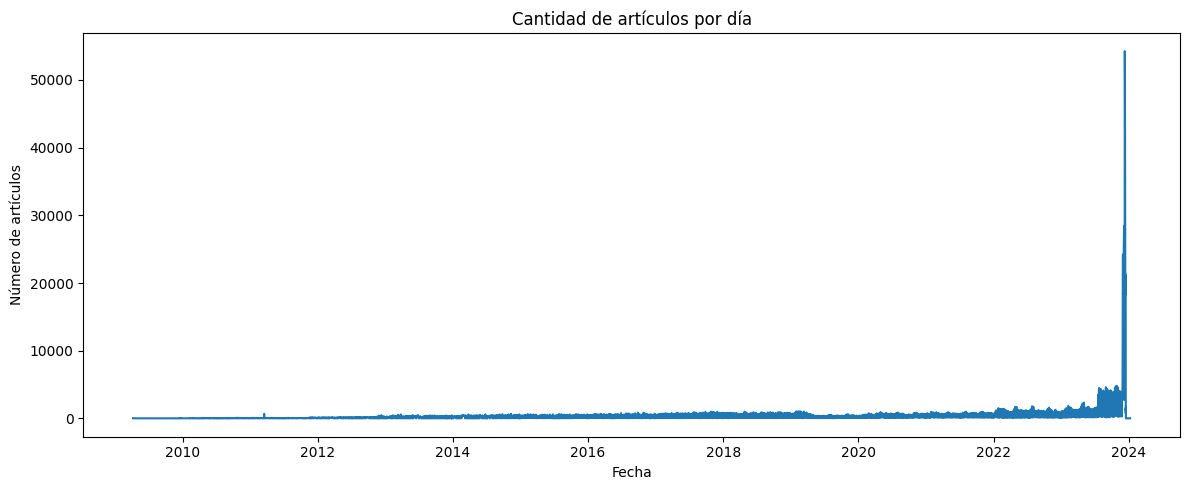

In [19]:
# Convertir la columna Date a tipo datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Agrupar por fecha y contar artículos
articulos_por_dia = df_clean.groupby('Date').size()

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(articulos_por_dia.index, articulos_por_dia.values)
plt.title('Cantidad de artículos por día')
plt.xlabel('Fecha')
plt.ylabel('Número de artículos')
plt.tight_layout()
plt.show()

In [20]:
# Convertir a datetime si no está hecho
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Filtrar años 2000-2020
df_clean = df_clean[(df_clean['Date'].dt.year >= 2000) & (df_clean['Date'].dt.year <= 2020)]

# Agrupar por día y contar artículos
articulos_por_dia = df_clean.groupby('Date').size()

# Crear un índice de fechas completo
fecha_inicio = df_clean['Date'].min()
fecha_fin = df_clean['Date'].max()
fechas_completas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Reindexar para que los días sin artículos aparezcan con 0
articulos_por_dia = articulos_por_dia.reindex(fechas_completas, fill_value=0)


In [21]:
# df_clean: tu sub-DataFrame filtrado y con Date tipo datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Filtrar años 2000-2020
df_clean = df_clean[(df_clean['Date'].dt.year >= 2000) & (df_clean['Date'].dt.year <= 2020)]

# Contar artículos por día
articulos_por_dia = df_clean.groupby('Date').size()

# Crear índice de fechas completo
fecha_inicio = df_clean['Date'].min()
fecha_fin = df_clean['Date'].max()
fechas_completas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Reindexar para que los días sin artículos aparezcan con 0
articulos_por_dia = articulos_por_dia.reindex(fechas_completas, fill_value=0)

# Pasar a DataFrame
df_dias = articulos_por_dia.reset_index()
df_dias.columns = ['Date', 'count']

# Crear columna Año-Mes como string
df_dias['YearMonth'] = df_dias['Date'].dt.strftime('%Y-%m')

# Contar días sin artículos por mes, incluyendo meses sin huecos
dias_sin_articulos = df_dias.groupby('YearMonth').apply(lambda x: (x['count'] == 0).sum())

# Mostrar resultados
print(dias_sin_articulos)

YearMonth
2009-04    18
2009-05    28
2009-06    21
2009-07    15
2009-08    19
           ..
2020-08     0
2020-09     0
2020-10     0
2020-11     0
2020-12     0
Length: 141, dtype: int64


C:\Users\Ceci\AppData\Local\Temp\ipykernel_10120\625314996.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dias_sin_articulos = df_dias.groupby('YearMonth').apply(lambda x: (x['count'] == 0).sum())


In [23]:
dias_sin_articulos.to_csv('outputs/nasdaq_dias_sin_articulos.csv', header=['Dias_sin_articulos'])


In [ ]:
#según esto, desde ene-2015 hasta dic-2020 hay al menos un artículo en la gran mayoría de los días (hay unos pocos meses con un día sin artículos).

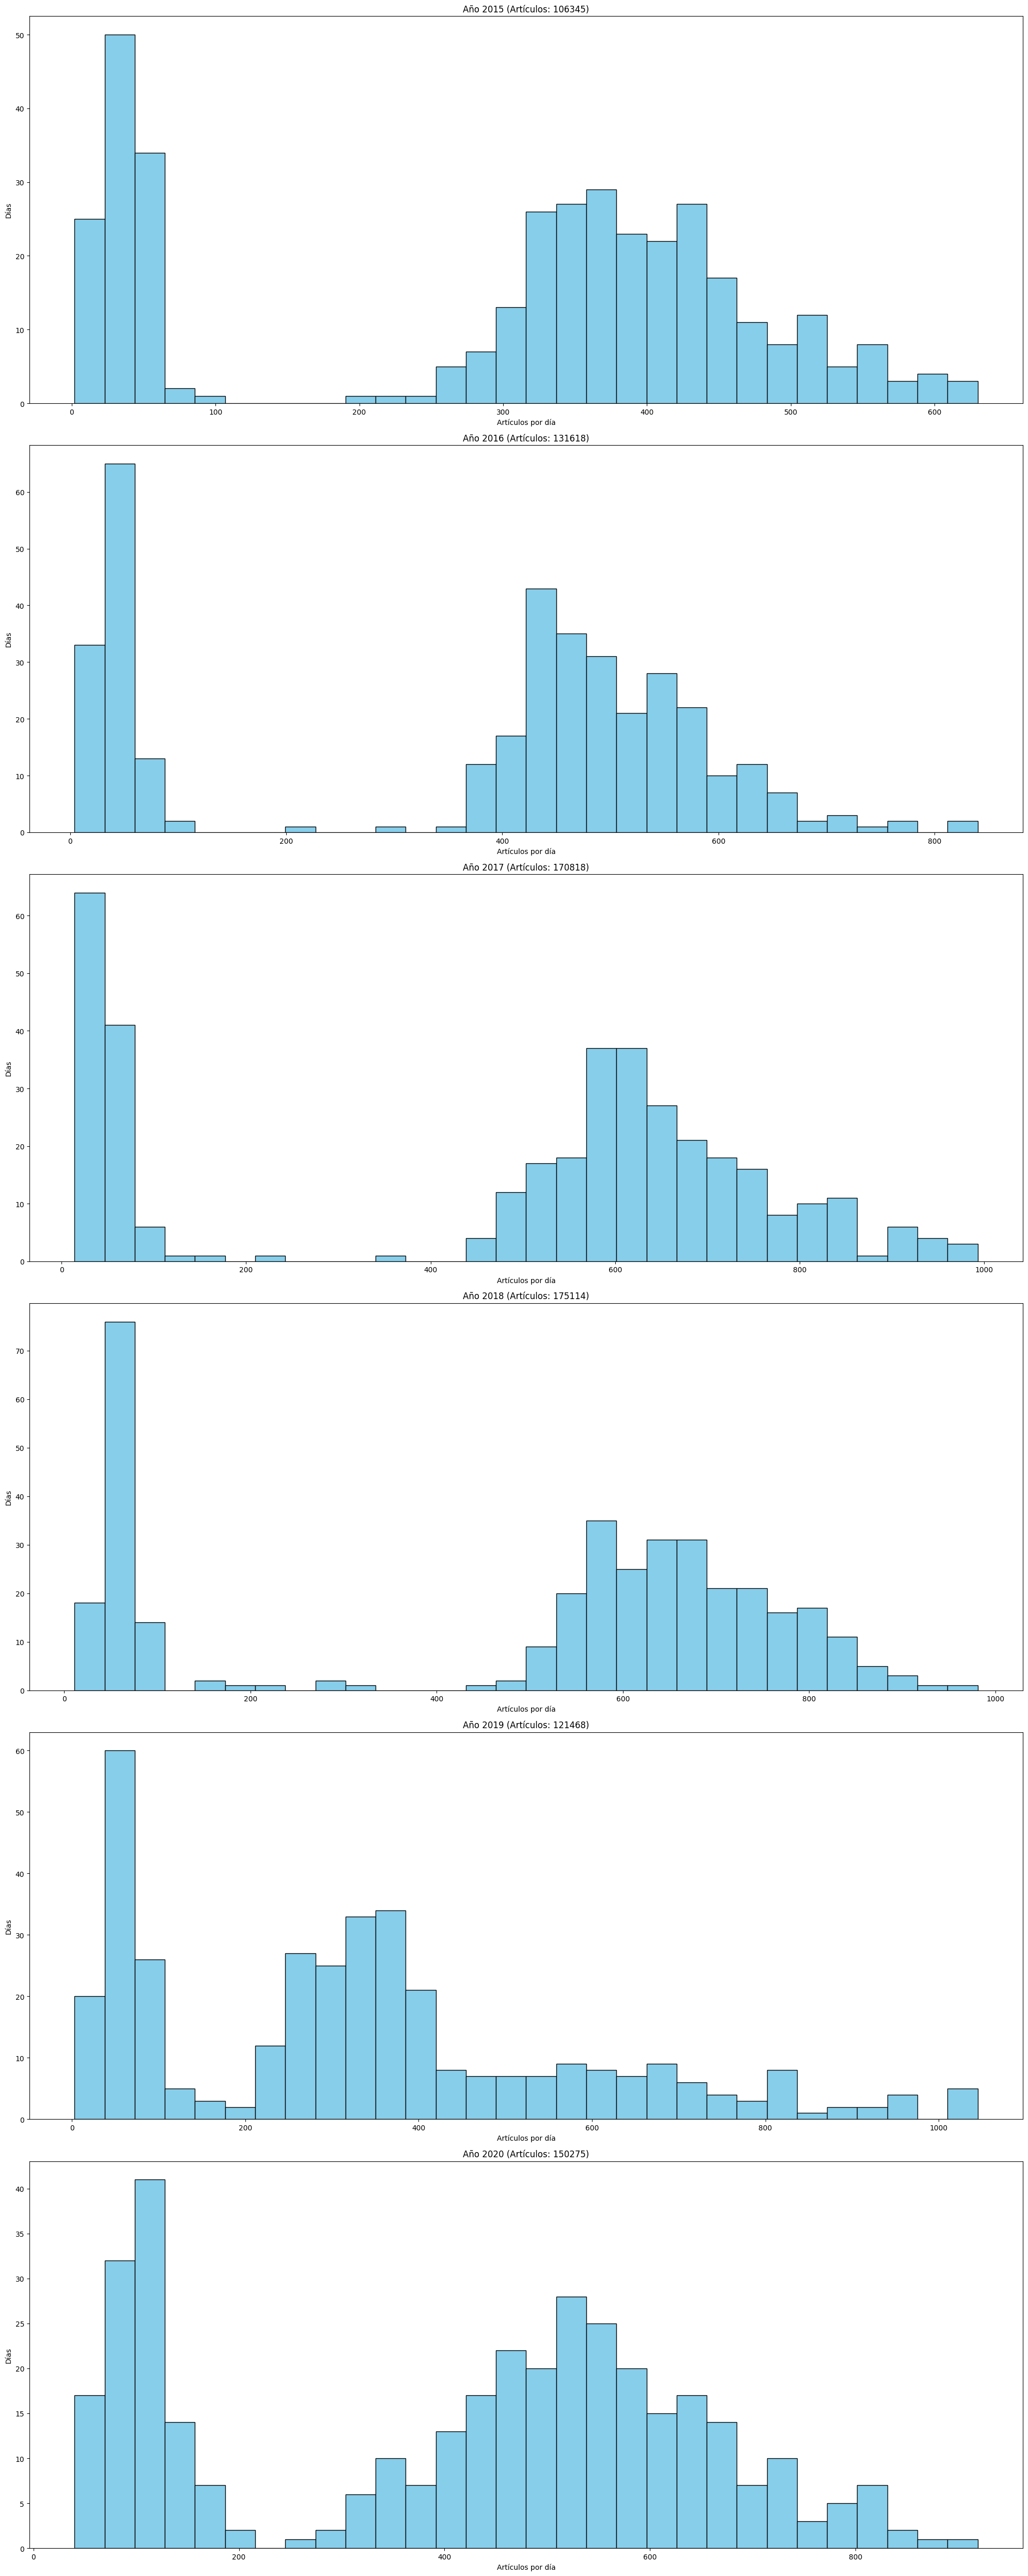

In [29]:
# df_clean: tu sub-DataFrame filtrado con las 3 columnas no nulas
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean = df_clean[(df_clean['Date'].dt.year >= 2015) & (df_clean['Date'].dt.year <= 2020)]

# Contar artículos por día
articulos_por_dia = df_clean.groupby('Date').size()

# Crear DataFrame con año
df_dias = articulos_por_dia.reset_index()
df_dias.columns = ['Date', 'count']
df_dias['Year'] = df_dias['Date'].dt.year

# Configuración de subplots: 10 filas x 3 columnas
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(20, 50), sharex=False, sharey=False)
axes = axes.flatten()

years = range(2015, 2021)
for i, year in enumerate(years):
    ax = axes[i]
    data_year = df_dias[df_dias['Year'] == year]['count']
    
    # Histograma
    ax.hist(data_year, bins=30, color='skyblue', edgecolor='black')
    
    # Contar total de artículos en ese año
    total_articulos = data_year.sum()
    
    # Título con año + total de artículos
    ax.set_title(f'Año {year} (Artículos: {total_articulos})')
    ax.set_xlabel('Artículos por día')
    ax.set_ylabel('Días')
    
# Ocultar subplots sobrantes
for j in range(len(years), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# A priori, entrenar en 2017 y testear en 2018 parece ok
# 2019 y 2020 son los histogramas con distr mas uniformes, pero no quiero predecir en 2020 por el efecto de la pandemia